## Buenas prácticas al graficar
Ejemplo básico: lineplot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
%matplotlib inline

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')

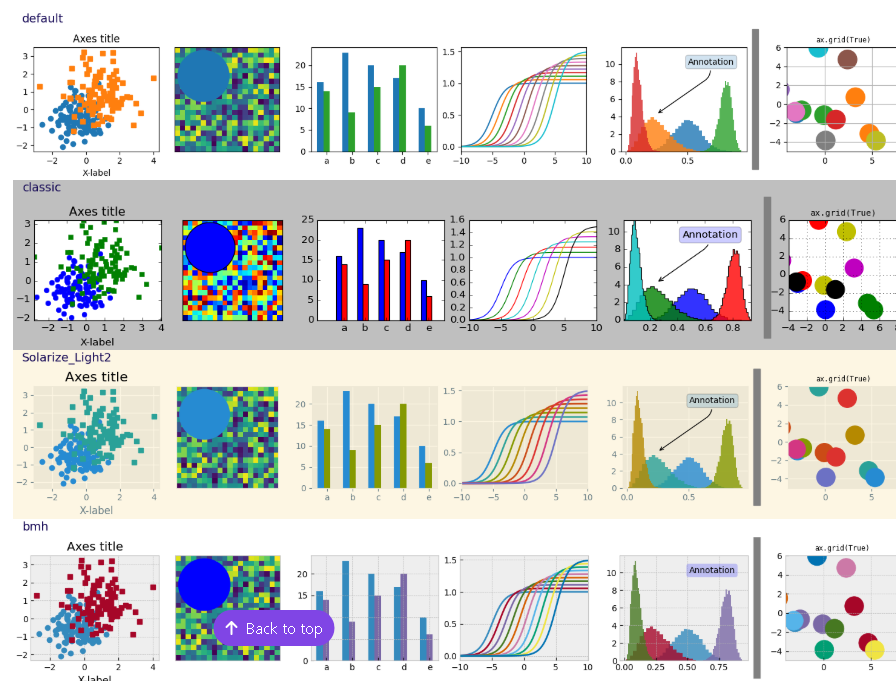

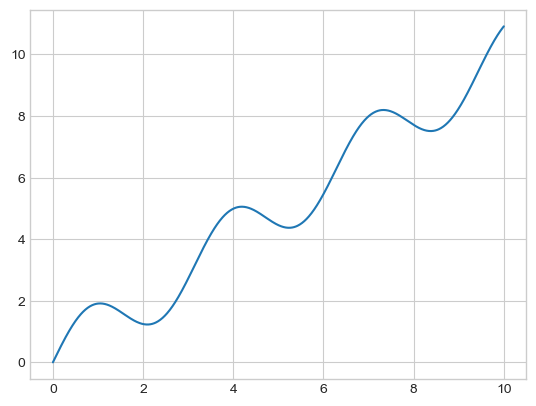

In [3]:
fig = plt.figure()
ax = plt.axes()
x = np.linspace(0,10,1000)
ax.plot(x, np.sin(2*x)+x);

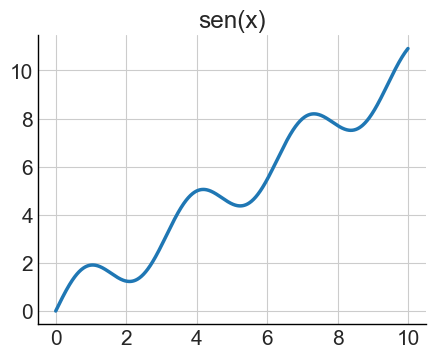

In [4]:
fig = plt.figure(figsize = (5, 3.75))
ax = plt.axes()
x = np.linspace(0,10,1000)
ax.plot(x, np.sin(2*x)+x, linewidth = 2.5)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
ax.set_title("sen(x)", fontsize = 17.5)
ax.spines.top.set_visible(False)    
ax.spines.right.set_visible(False)
ax.spines.left.set_color('black')
ax.spines.bottom.set_color('black')

Ejemplo: Porcentaje de títulos de licenciatura otorgados a mujeres en Estados unidos, por especialización (1970-2012)

Text(1995, 93, 'Porcentaje de grados otorgados a mujeres en EUA, por grado (1970-2012)')

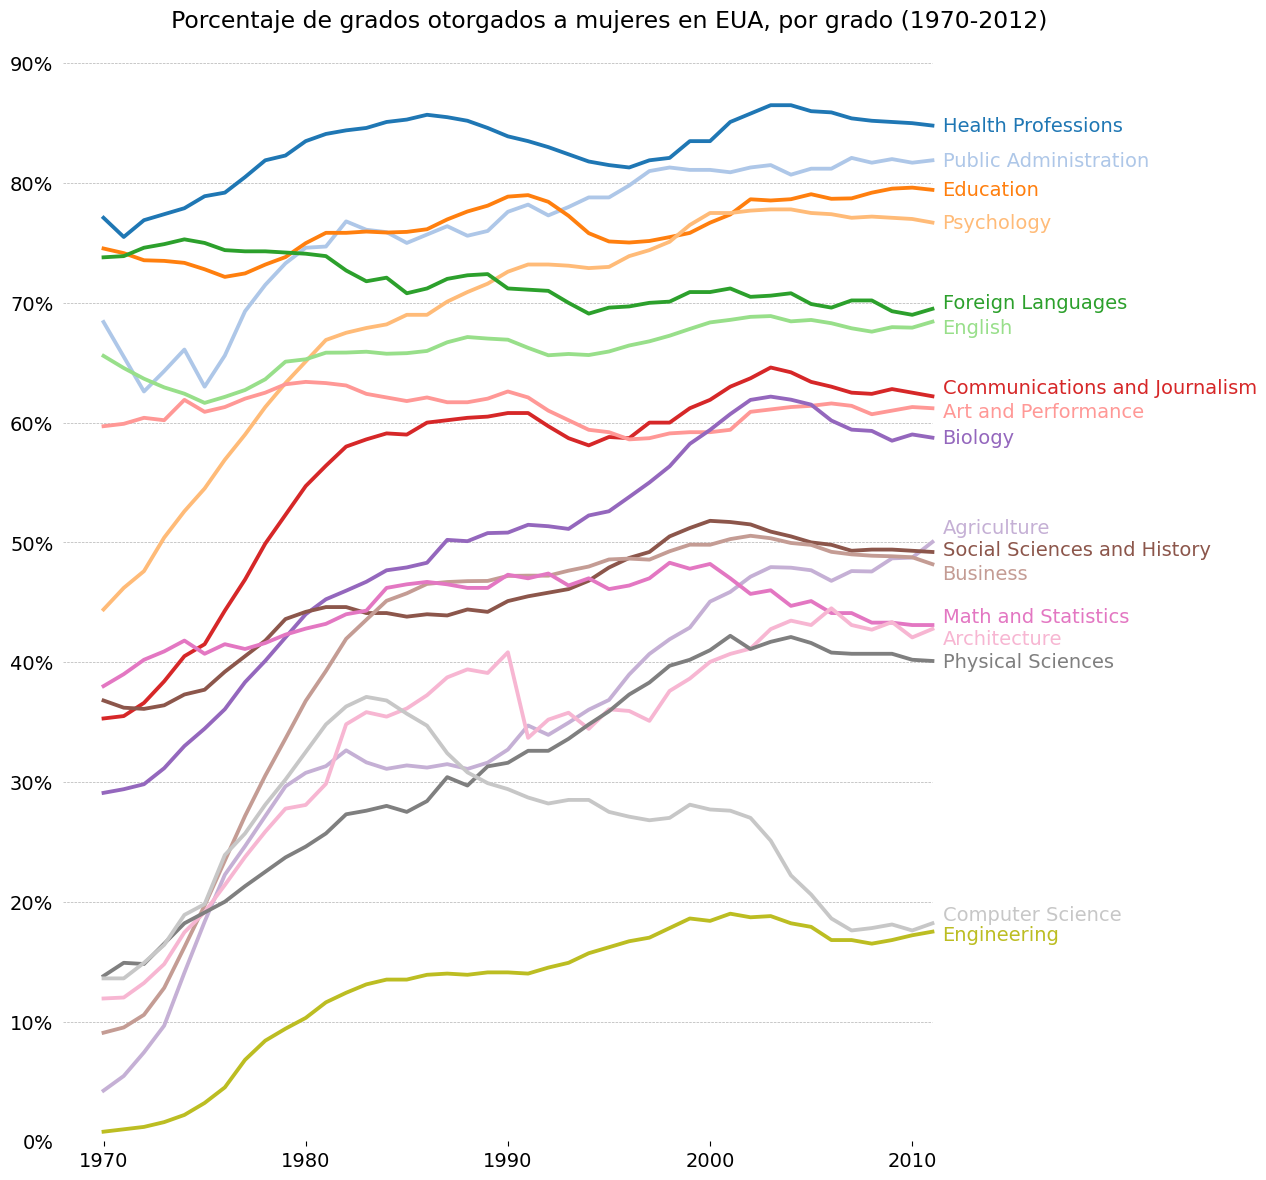

In [ ]:
plt.style.use('default')
# Leemos los datos del csv
grado_genero = pd.read_csv("Datasets/percent-bachelors-degrees-women-usa.csv")
# Usaremos la paleta de colores de Tableau, dada aquí en RGB
tableau20 = [(31, 119, 180), (174, 199, 232), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (197, 176, 213), (140, 86, 75), (196, 156, 148),
             (227, 119, 194), (247, 182, 210), (127, 127, 127), (199, 199, 199),
             (188, 189, 34), (219, 219, 141), (23, 190, 207), (158, 218, 229)]
# Los escalamos al intervalo [0,1]
for k in range(len(tableau20)):
    R, G, B = tableau20[k]
    tableau20[k] = (R/255., G/255., B/255.)

# Se recomienda en general que la gráfica sea ~x1.33-x1.65 más ancha que alta.
# En esta gráfica esto no se cumple por el número de lineas a graficar.
plt.figure(figsize=(12,14))

# Muchas veces se ve visualmente mejor remover las líneas del marco.
# Esto depende de lo que se esté graficando y el estilo que se desee.
ax = plt.subplot(111) 
for s in ["top", "bottom", "right", "left"]:
    ax.spines[s].set_visible(False)

# Idealmente se debe procurar utilizar al máximo el espacio de graficación.
# Evitando espacios en blanco innecesarios
plt.ylim(0,90)
plt.xlim(1968,2014)

# El texto en la gráfica debe ser de preferencia grande, no solo suficientemente grande.
# Para garantizar legibilidad
plt.yticks(range(0,91,10), [str(x) + "%" for x in range(0,91,10)], fontsize = 14)
plt.xticks(fontsize = 14)

# En lugar de usar una cuadrícula, proyectaremos los ticks a lo largo de la gráfica
# Uilizando un color claro y tamaño pequeño para que no atiborre la figura
for y in range(10,91,10):
    plt.plot(range(1968, 2012), np.repeat(y, len(range(1968, 2012))), "--", lw=0.5,
            color="black", alpha=0.3)
# Con estas líneas los tick marks se vuelven innecesarios
plt.tick_params(axis = "both", which = "both", top = False, 
               labelbottom = True, left = False, labelleft = True)

# Esto fue preparación de la figura donde se graficaremos los datos.
# Ahora sí hagamos esto último.
# Los grados están ordenados de mayor a menor % en el último año
grados = ['Health Professions', 'Public Administration', 'Education', 'Psychology',  
          'Foreign Languages', 'English', 'Communications and Journalism',  
          'Art and Performance', 'Biology', 'Agriculture',  
          'Social Sciences and History', 'Business', 'Math and Statistics',  
          'Architecture', 'Physical Sciences', 'Computer Science',  
          'Engineering']

for rank, column in enumerate(grados):
    # Graficamos cada serie con un diferente color
    plt.plot(grado_genero.Year.values,  
             grado_genero[column].values,  
             lw=2.75, color=tableau20[rank])
    # Agregamos una etiqueta con el nombre del grado al final de cada línea
    # Se ajusta más arriba o abajo su posición para que no se traslapen
    y_pos = grado_genero[column].values[-1] - 0.5  
    if column == "Foreign Languages":  
        y_pos += 0.5  
    elif column == "English":  
        y_pos -= 0.5  
    elif column == "Communications and Journalism":  
        y_pos += 0.75  
    elif column == "Art and Performance":  
        y_pos -= 0.25  
    elif column == "Agriculture":  
        y_pos += 1.25  
    elif column == "Social Sciences and History":  
        y_pos += 0.25  
    elif column == "Business":  
        y_pos -= 0.75  
    elif column == "Math and Statistics":  
        y_pos += 0.75  
    elif column == "Architecture":  
        y_pos -= 0.75  
    elif column == "Computer Science":  
        y_pos += 0.75  
    elif column == "Engineering":  
        y_pos -= 0.25  

    # Escribimos las etiquetas y nos aseguramos que sean legibles.
    # Proporcionamos la coordenada del último año y y_pos
    plt.text(2011.5, y_pos, column, fontsize = 14, color = tableau20[rank])

# En ocasiones si el título es lo suficientemente descriptivo, no es necesario 
# incluir títulos de los ejes; son evidentes como en este caso.
# En otros casos se pueden poner títulos de ejes y un pie de imagen, con lo cual
# se vuelve innecesario poner un título en la gráfica misma
plt.text(1995, 93, "Porcentaje de grados otorgados a mujeres en EUA"  
       ", por grado (1970-2012)", fontsize=17, ha="center")  
#plt.title("Porcentaje de grados otorgados a mujeres en EUA, por grado (1970-2012)",
#           fontsize = 17)


### Ejercicio

In [6]:
x = np.arange(25)
y = np.random.randint(10, 20, 25)
y[24] = y[0]

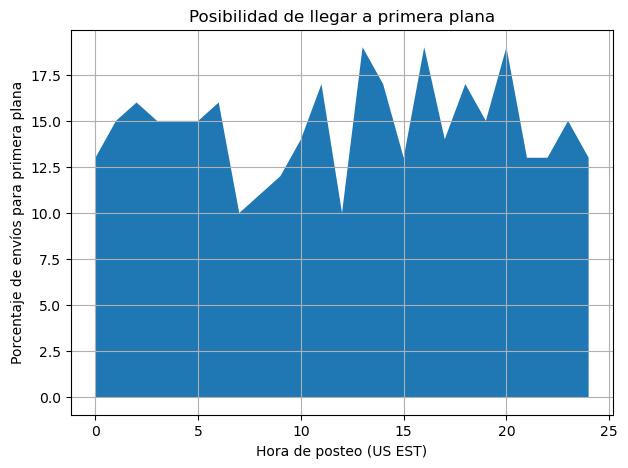

In [7]:
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(111)
ax.fill_between(x, y)

ax.set_xlabel('Hora de posteo (US EST)')
ax.set_ylabel('Porcentaje de envíos para primera plana')
ax.set_title('Posibilidad de llegar a primera plana')

ax.grid('on')

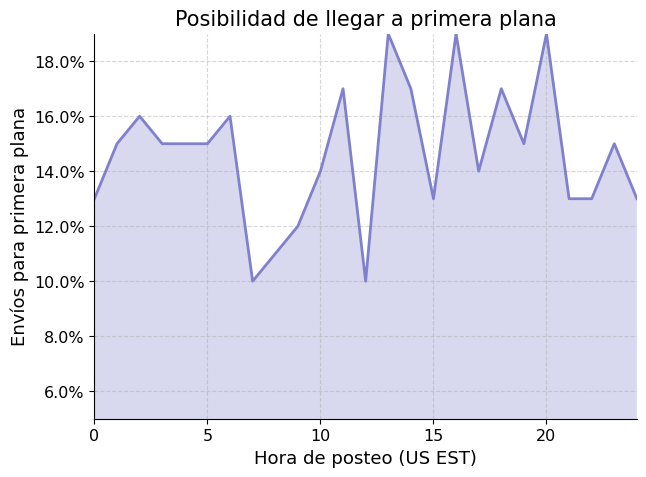

In [8]:
fig = plt.figure(figsize=(7,5))
plt.plot(x, y, color = (.5, .5, .8), linewidth = 2)
ax = plt.subplot(111)
ax.fill_between(x, y, facecolor = (.5, .5, .8, .3))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim((min(x), max(x)))
ax.set_ylim((0.5*min(y), max(y)))
ax.set_xlabel('Hora de posteo (US EST)', fontsize = 13)
ax.set_ylabel('Envíos para primera plana', fontsize = 13)
ax.set_title('Posibilidad de llegar a primera plana', fontsize = 15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 11.5)
ax.grid('on', alpha = 0.5, linestyle = '--')

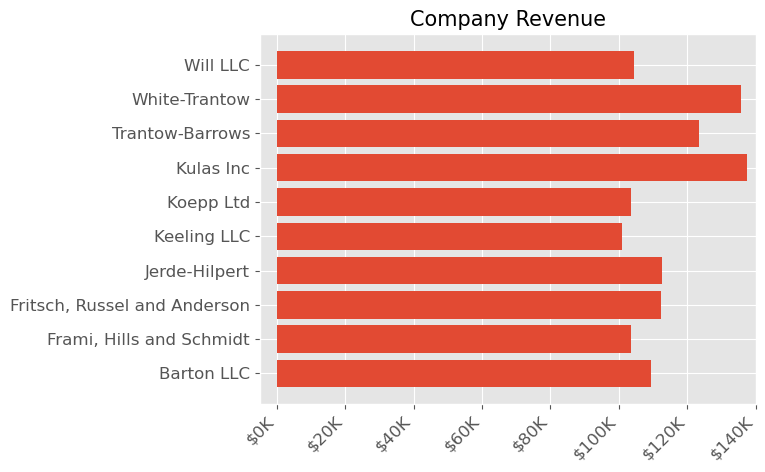

In [9]:
plt.style.use("ggplot")
data = {'Barton LLC': 109438.50,
        'Frami, Hills and Schmidt': 103569.59,
        'Fritsch, Russel and Anderson': 112214.71,
        'Jerde-Hilpert': 112591.43,
        'Keeling LLC': 100934.30,
        'Koepp Ltd': 103660.54,
        'Kulas Inc': 137351.96,
        'Trantow-Barrows': 123381.38,
        'White-Trantow': 135841.99,
        'Will LLC': 104437.60}
group_data = list(data.values())
group_names = list(data.keys())
group_mean = np.mean(group_data)
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right', fontsize = 12);
plt.yticks(fontsize = 12)
ax.set(xlim=[-5000, 140000])
plt.title('Company Revenue', fontsize = 15)
# Para que se pueda usar como formato en Axis.set_major_formatter necesitamos que la función tome el argumento de posición del tick
def currency(x, pos):
    """The two arguments are the value and tick position"""
    if x >= 1e6:
        s = f'${x*1e-6:1.1f}M'
    else:
        s = f'${x*1e-3:1.0f}K'
    return s
ax.xaxis.set_major_formatter(currency)

Text(0, 0.5, 'sepal width (cm)')

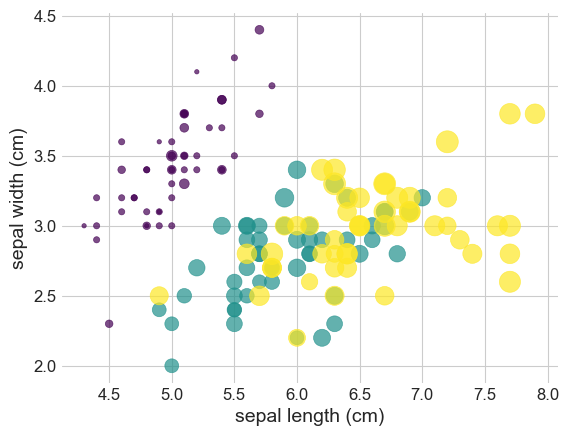

In [10]:
from sklearn.datasets import load_iris
plt.style.use('seaborn-v0_8-whitegrid')
iris = load_iris()
features = iris.data.T
plt.scatter(features[0], features[1], alpha = 0.7, s = 100*features[3], c = iris.target, cmap = 'viridis')
ax = plt.subplot(111) 
for s in ["top", "bottom", "right", "left"]:
    ax.spines[s].set_visible(False)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel(iris.feature_names[0], fontsize = 14)
plt.ylabel(iris.feature_names[1], fontsize = 14)

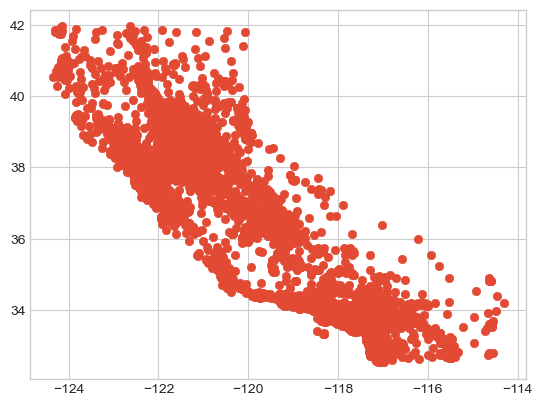

In [ ]:
CA_housing = pd.read_csv("Datasets/housing.csv")
plt.scatter(CA_housing.longitude, CA_housing.latitude)

Text(0.5, 1.0, 'Distritos, censo de California (1990)')

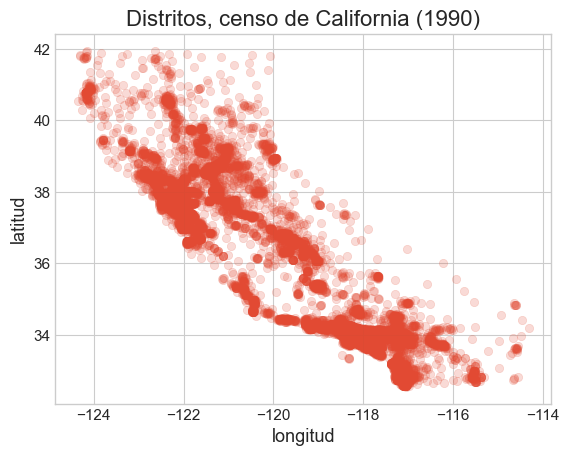

In [12]:
plt.scatter(CA_housing.longitude, CA_housing.latitude, alpha = 0.2)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel('longitud', fontsize = 13)
plt.ylabel('latitud', fontsize = 13)
plt.title('Distritos, censo de California (1990)', fontsize = 16)

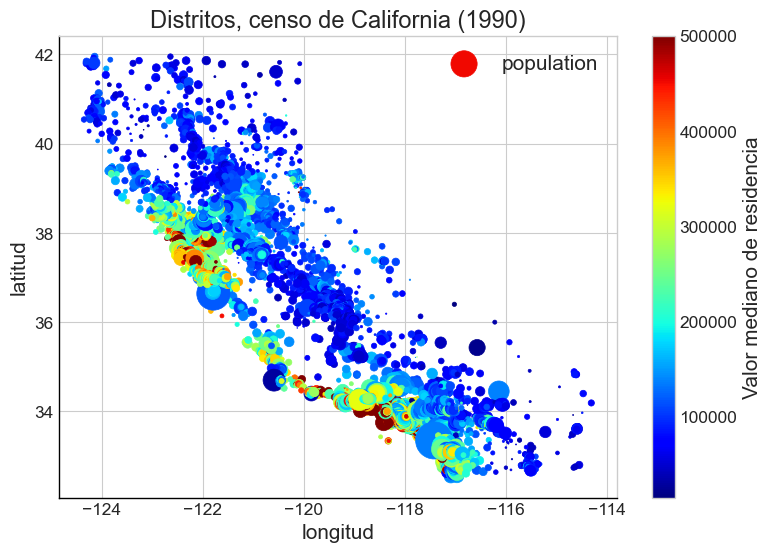

In [13]:
plt.figure(figsize = (9, 6))
ax = plt.subplot(111)
ax.spines.left.set_color('black')
ax.spines.bottom.set_color('black')
plt.scatter(CA_housing.longitude, CA_housing.latitude, s = CA_housing.population/50, label = 'population',
           c = CA_housing.median_house_value, cmap = 'jet')
plt.xticks(fontsize = 12.5)
plt.yticks(fontsize = 12.5)
plt.xlabel('longitud', fontsize = 15)
plt.ylabel('latitud', fontsize = 15)
plt.title('Distritos, censo de California (1990)', fontsize = 17)
plt.legend(fontsize = 15)
cb = plt.colorbar()
cb.set_label(label = 'Valor mediano de residencia', size = 15)
cb.ax.tick_params(labelsize=12.5) 

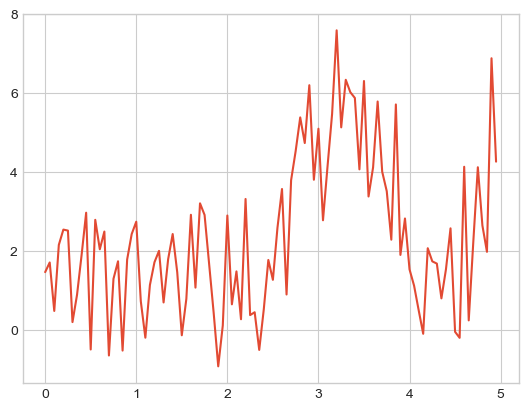

In [14]:
x = np.arange(0, 5, .05)
y = 0.5*np.exp(0.5*x+np.sin(2.5*x))+1.25*np.random.randn(100)
plt.plot(x,y)

In [15]:
err = 1.25*np.random.rand(100)
for i in range(100):
    err[i] *= 2/np.power(i+1, 1/3)

Text(0.5, 1.0, 'Un buen título va aquí')

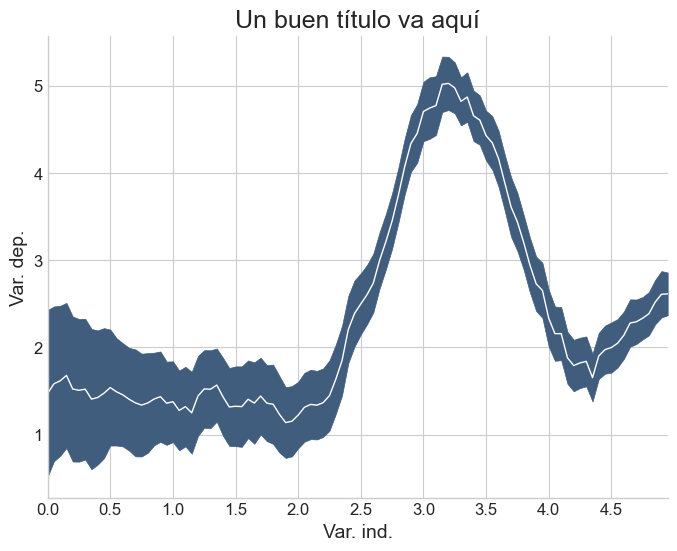

In [16]:
def media_movil(datos, ventana = 10):
    nva_lista = []
    for i in range(len(datos)):
        indices = range(max(i-ventana+1, 0), min(i+ventana+1, len(datos)))
        prom = 0
        for j in indices:
            prom += datos[j]
        prom /= float(len(indices))
        nva_lista.append(prom)
    return np.array(nva_lista)
y = media_movil(y)
err = media_movil(err)
plt.figure(figsize = (8, 6))
ax = plt.subplot()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xlim(min(x), max(x))
plt.xticks(np.arange(0,5,0.5), fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylabel("Var. dep.", fontsize = 14)
plt.xlabel("Var. ind.", fontsize = 14)
ax.fill_between(x, y-err, y+err, color = (64/255., 93/255., 125/255.))
ax.plot(x, y, color = "white", lw = 1)
plt.title("Un buen título va aquí", fontsize = 18)